# QTCAD M05 Many-body — Full Result Analysis

이 노트북은 아래 QTCAD 예제 폴더의 **기존 결과를 수정하지 않고** 읽어서, nanowire many-body 예제와 FD-SOI double-dot exchange 예제를 한 번에 분석합니다.

**Base directory**

`C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M05. Many-body\Reference`

분석 대상:
- `nanowire.py`, `manybody.py`, `exchange_1.py`, `exchange_2.py`
- `helper/double_dot_fdsoi.py`
- `meshes/nanowire.geo`, `meshes/nanowire.msh`
- `meshes/dqdfdsoi.geo`, `meshes/dqdfdsoi.msh`, `meshes/refined_dqdfdsoi.msh`
- `output/nanowire.hdf5`, `output/nanowire.vtu`
- `output/nanowire_energies.txt`, `output/nanowire_linecuts_x.txt`, `output/nanowire_linecuts_z.txt`
- `output/tunnel_coupling_final_potential.hdf5`, `output/tunnel_coupling_low_barrier.txt`
- `output/detuned_potential.hdf5`
- `output/exchange_localized_wavefunctions.vtu`
- `output/exchange_coulomb_localized.txt`
- `output/exchange_perturbation.txt`
- `output/exchange_two_electron_energies.txt`

주요 산출물:
1. 파일 dependency / 실행 흐름 확인
2. nanowire 및 double-dot geometry / Physical group 검증
3. nanowire single-particle energy 및 level spacing
4. nanowire electrostatic potential / carrier linecut
5. nanowire HDF5 구조 및 통계
6. **선택 실행:** `manybody.py`의 many-body 계산 재현
7. double-dot tunnel-coupling 입력값 단위 환산
8. localized-basis Coulomb matrix 분석
9. perturbation theory exchange coupling 재계산
10. exact diagonalization two-electron spectrum 분석
11. perturbative / exact exchange coupling 정량 비교
12. detuning 전후 electrostatic potential 차이
13. localized wavefunction VTU peak / slice / line profile
14. CSV / PNG 분석 결과 자동 저장

> 원본 QTCAD 파일은 수정하지 않습니다. 새 산출물은 `Reference\analysis_exports_M05`에 저장합니다.


---
## 📚 참고 문서
- **QTCAD 공식 튜토리얼** — Device 14: Many-body analysis of a nanowire quantum dot
  https://docs.nanoacademic.com/qtcad/tutorials/device/manybody/
- **QTCAD 공식 튜토리얼** — Device 19 Part 2: Exchange coupling in a DQD in FD-SOI — Exact diagonalization
  https://docs.nanoacademic.com/qtcad/tutorials/device/exchange_2/
- **QTCAD 공식 튜토리얼** — A double quantum dot device in FD-SOI
  https://docs.nanoacademic.com/qtcad/tutorials/device/double_dot_fdsoi/
- **QTCAD 문서 포털**: https://docs.nanoacademic.com/qtcad/
- 소스 스크립트: `nanowire.py`, `manybody.py`, `exchange_1.py`, `exchange_2.py` (M05/Reference)
---


## 0. 두 소자의 스케매틱 + 파라미터 선택 의도

**(a) nanowire.py/manybody.py**: `nanowire.geo` 치수(반지름 r0=1.5nm 원통형 채널,
길이 L=10nm, source/drain 연장 Lc=5nm씩, 산화막 두께 tox=1nm)를 그대로 재구성한
측면도입니다.

**(b) exchange_2.py**: M16/M04와 동일한 FD-SOI 이중양자점(`dqdfdsoi.geo`).

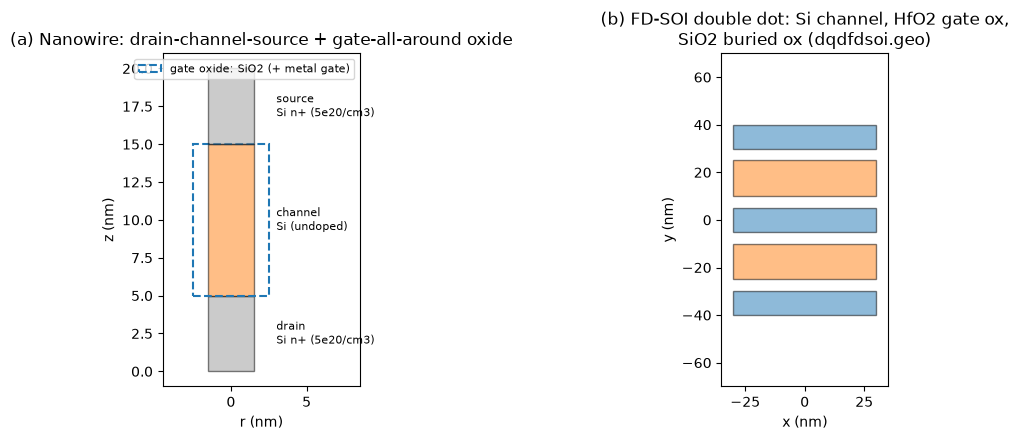

,parameter,intent
0,"nanowire r0=1.5nm, L=10nm, Lc=5nm, tox=1nm",실린더형 나노와이어 FET 표준 축소 모형 — 반지름 1.5nm는 강한 양자구속을 ...
1,num_states (manybody N=0~3 addition energy),소수 전자(0~3개) 영역의 Coulomb blockade를 보기 위한 최소 상태 ...
2,exchange_2: num_states=2 (exact diagonalization),2-site Hubbard 모형(M16 1절)과 동일하게 dot1/dot2 국소화 ...


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

BASE_DIR = Path(
    r"C:\\Users\\norma\\Desktop\\연구자료\\QTCAD Simulation\\Simulation Example\\M05. Many-body\\Reference"
)
EXPORT_DIR = BASE_DIR / "analysis_exports_M05"
EXPORT_DIR.mkdir(exist_ok=True)

# [실험] (a) 나노와이어 측면 스케매틱 (nanowire.geo 치수 그대로)
import matplotlib.patches as mpatches

r0, L, Lc, tox = 1.5, 10.0, 5.0, 1.0
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axs[0]
z0 = 0
nw_mats = {"drain": "Si n+ (5e20/cm3)", "channel": "Si (undoped)", "source": "Si n+ (5e20/cm3)"}
for name, h, color in [("drain", Lc, "0.6"), ("channel", L, "tab:orange"), ("source", Lc, "0.6")]:
    ax.add_patch(mpatches.Rectangle((-r0, z0), 2*r0, h, fc=color, alpha=0.5, ec="k"))
    if name == "channel":
        ax.add_patch(mpatches.Rectangle((-r0-tox, z0), 2*(r0+tox), h, fc="none", ec="tab:blue",
                                        ls="--", lw=1.5, label="gate oxide: SiO2 (+ metal gate)"))
    ax.text(r0 + tox + 0.5, z0 + h/2, f"{name}\n{nw_mats[name]}", va="center", fontsize=8)
    z0 += h
ax.set_xlim(-r0-tox-2, r0+tox+6); ax.set_ylim(-1, z0+1)
ax.set_aspect("equal"); ax.set_xlabel("r (nm)"); ax.set_ylabel("z (nm)")
ax.set_title("(a) Nanowire: drain-channel-source + gate-all-around oxide")
ax.legend(fontsize=8)

ax2 = axs[1]
domain_width, channel_width = 60.0, 40.0
gaps = [5.0]*6; barrier_len, plunger_len, sd_len = 10.0, 15.0, 20.0
channel_len = sum(gaps) + 3*barrier_len + 2*plunger_len
domain_len = 2*sd_len + channel_len
temp = -channel_len/2 + gaps[0]
lens = [barrier_len, plunger_len, barrier_len, plunger_len, barrier_len]
names = ["barrier_gate_1","plunger_gate_1","barrier_gate_2","plunger_gate_2","barrier_gate_3"]
for name, Lseg, gi in zip(names, lens, [1,2,3,4,5]):
    ax2.add_patch(mpatches.Rectangle((-domain_width/2, temp), domain_width, Lseg,
                  fc="tab:orange" if "plunger" in name else "tab:blue", alpha=0.5, ec="k"))
    temp += gaps[gi] + Lseg
ax2.set_xlim(-domain_width/2-5, domain_width/2+5); ax2.set_ylim(-domain_len/2-5, domain_len/2+5)
ax2.set_aspect("equal"); ax2.set_xlabel("x (nm)"); ax2.set_ylabel("y (nm)")
ax2.set_title("(b) FD-SOI double dot: Si channel, HfO2 gate ox,\nSiO2 buried ox (dqdfdsoi.geo)")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "device_schematics_M05.png", dpi=150)
plt.show()

param_intent_m05 = pd.DataFrame([
    {"parameter": "nanowire r0=1.5nm, L=10nm, Lc=5nm, tox=1nm",
     "intent": "실린더형 나노와이어 FET 표준 축소 모형 — 반지름 1.5nm는 강한 양자구속을 "
               "주기 위한 얇은 채널, source/drain 5nm는 접촉 저항을 무시할 만큼만 "
               "확장(도핑 1e20/cm^3로 사실상 금속처럼 취급)."},
    {"parameter": "num_states (manybody N=0~3 addition energy)",
     "intent": "소수 전자(0~3개) 영역의 Coulomb blockade를 보기 위한 최소 상태 수 — "
               "single-electron operating window 추정이 M05의 미팅 질문이므로 더 "
               "많은 전자 수는 불필요."},
    {"parameter": "exchange_2: num_states=2 (exact diagonalization)",
     "intent": "2-site Hubbard 모형(M16 1절)과 동일하게 dot1/dot2 국소화 궤도 2개만 "
               "기저로 사용 — exact diagonalization이어도 기저가 작아야 '2차 섭동론과 "
               "비교 가능한' 같은 물리적 설정이 유지됨."},
])
display(param_intent_m05)
param_intent_m05.to_csv(EXPORT_DIR / "parameter_intent.csv", index=False)


In [2]:
# [동작] 기본 패키지 및 경로 설정
from pathlib import Path
from math import comb
import gc
import os
import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

from scipy.constants import e as elementary_charge
from scipy.constants import h as planck_h

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M05. Many-body\Reference"
)

# 다른 PC/폴더에서 시험할 때만 환경변수로 override 가능
# 예: set QTCAD_M05_BASE_DIR=D:\work\M05. Many-body\Reference
if os.environ.get("QTCAD_M05_BASE_DIR"):
    BASE_DIR = Path(os.environ["QTCAD_M05_BASE_DIR"])

OUTPUT_DIR = BASE_DIR / "output"
MESH_DIR = BASE_DIR / "meshes"
HELPER_DIR = BASE_DIR / "helper"
EXPORT_DIR = BASE_DIR / "analysis_exports_M05"
EXPORT_DIR.mkdir(exist_ok=True)

# Source files
FILE_NANOWIRE_PY = BASE_DIR / "nanowire.py"
FILE_MANYBODY_PY = BASE_DIR / "manybody.py"
FILE_EXCHANGE1_PY = BASE_DIR / "exchange_1.py"
FILE_EXCHANGE2_PY = BASE_DIR / "exchange_2.py"
FILE_DQD_HELPER = HELPER_DIR / "double_dot_fdsoi.py"

# Mesh / geometry
FILE_NW_GEO = MESH_DIR / "nanowire.geo"
FILE_NW_MSH = MESH_DIR / "nanowire.msh"
FILE_DQD_GEO = MESH_DIR / "dqdfdsoi.geo"
FILE_DQD_MSH = MESH_DIR / "dqdfdsoi.msh"
FILE_DQD_REFINED_MSH = MESH_DIR / "refined_dqdfdsoi.msh"

# Nanowire outputs
FILE_NW_HDF5 = OUTPUT_DIR / "nanowire.hdf5"
FILE_NW_VTU = OUTPUT_DIR / "nanowire.vtu"
FILE_NW_ENERGIES = OUTPUT_DIR / "nanowire_energies.txt"
FILE_NW_LINECUT_X = OUTPUT_DIR / "nanowire_linecuts_x.txt"
FILE_NW_LINECUT_Z = OUTPUT_DIR / "nanowire_linecuts_z.txt"

# Double-dot / exchange inputs and outputs
FILE_TUNNEL_PHI = OUTPUT_DIR / "tunnel_coupling_final_potential.hdf5"
FILE_TUNNEL_LOW = OUTPUT_DIR / "tunnel_coupling_low_barrier.txt"
FILE_DETUNED_PHI = OUTPUT_DIR / "detuned_potential.hdf5"
FILE_EXCHANGE_WF = OUTPUT_DIR / "exchange_localized_wavefunctions.vtu"
FILE_COULOMB = OUTPUT_DIR / "exchange_coulomb_localized.txt"
FILE_J_PERT = OUTPUT_DIR / "exchange_perturbation.txt"
FILE_TWO_E = OUTPUT_DIR / "exchange_two_electron_energies.txt"

# Plot / optional heavy analysis settings
SAVE_FIGURES = True
ANALYZE_LARGE_VTU = True
RUN_NANOWIRE_MANYBODY = False   # True로 바꾸면 manybody.py 핵심 계산을 notebook에서 재실행
Z_DQD_SLICE_NM = -2.0
LINE_RESOLUTION = 600

print("BASE_DIR  :", BASE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("MESH_DIR  :", MESH_DIR)
print("EXPORT_DIR:", EXPORT_DIR)


BASE_DIR  : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M05. Many-body\Reference
OUTPUT_DIR: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M05. Many-body\Reference\output
MESH_DIR  : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M05. Many-body\Reference\meshes
EXPORT_DIR: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M05. Many-body\Reference\analysis_exports_M05


In [3]:
# [점검] 파일 inventory
expected_files = {
    "nanowire.py": FILE_NANOWIRE_PY,
    "manybody.py": FILE_MANYBODY_PY,
    "exchange_1.py": FILE_EXCHANGE1_PY,
    "exchange_2.py": FILE_EXCHANGE2_PY,
    "helper/double_dot_fdsoi.py": FILE_DQD_HELPER,
    "meshes/nanowire.geo": FILE_NW_GEO,
    "meshes/nanowire.msh": FILE_NW_MSH,
    "meshes/dqdfdsoi.geo": FILE_DQD_GEO,
    "meshes/dqdfdsoi.msh": FILE_DQD_MSH,
    "meshes/refined_dqdfdsoi.msh": FILE_DQD_REFINED_MSH,
    "output/nanowire.hdf5": FILE_NW_HDF5,
    "output/nanowire.vtu": FILE_NW_VTU,
    "output/nanowire_energies.txt": FILE_NW_ENERGIES,
    "output/nanowire_linecuts_x.txt": FILE_NW_LINECUT_X,
    "output/nanowire_linecuts_z.txt": FILE_NW_LINECUT_Z,
    "output/tunnel_coupling_final_potential.hdf5": FILE_TUNNEL_PHI,
    "output/tunnel_coupling_low_barrier.txt": FILE_TUNNEL_LOW,
    "output/detuned_potential.hdf5": FILE_DETUNED_PHI,
    "output/exchange_localized_wavefunctions.vtu": FILE_EXCHANGE_WF,
    "output/exchange_coulomb_localized.txt": FILE_COULOMB,
    "output/exchange_perturbation.txt": FILE_J_PERT,
    "output/exchange_two_electron_energies.txt": FILE_TWO_E,
}

rows = []
for label, path in expected_files.items():
    rows.append({
        "file": label,
        "exists": path.exists(),
        "size_MB": path.stat().st_size / (1024**2) if path.exists() else np.nan,
        "path": str(path),
    })

inventory_df = pd.DataFrame(rows)
display(inventory_df)

missing = inventory_df.loc[~inventory_df["exists"], "file"].tolist()
if missing:
    print("\n[주의] 없는 파일:")
    for x in missing:
        print(" -", x)
else:
    print("\n[OK] 분석 대상 파일이 모두 존재합니다.")


,file,exists,size_MB,path
0,nanowire.py,True,0.004978,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
1,manybody.py,True,0.004430,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
2,exchange_1.py,True,0.003988,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
3,exchange_2.py,True,0.003966,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
4,helper/double_dot_fdsoi.py,True,0.002524,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
5,meshes/nanowire.geo,True,0.003079,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
6,meshes/nanowire.msh,True,4.287333,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
7,meshes/dqdfdsoi.geo,True,0.004639,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
8,meshes/dqdfdsoi.msh,True,0.246776,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
9,meshes/refined_dqdfdsoi.msh,True,43.106817,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...



[OK] 분석 대상 파일이 모두 존재합니다.


## 1. 예제 dependency / 실행 흐름

M05는 사실상 두 흐름으로 나뉩니다.

**Nanowire many-body**

`nanowire.msh → nanowire.py → nanowire.hdf5 → manybody.py`

**Double-dot exchange**

`tunnel_coupling_* prerequisite → exchange_1.py → exchange_perturbation.txt → exchange_2.py`

`helper/double_dot_fdsoi.py`는 double-dot의 material / boundary condition을 만드는 공통 device builder입니다.


In [4]:
# [점검] source code에서 핵심 dependency 문자열 확인
def source_contains(path, *tokens):
    text = path.read_text(encoding="utf-8", errors="ignore")
    return {token: (token in text) for token in tokens}

dependency_checks = {
    "nanowire.py": source_contains(
        FILE_NANOWIRE_PY,
        "nanowire.msh", "nanowire.hdf5", "nanowire_energies.txt"
    ),
    "manybody.py": source_contains(
        FILE_MANYBODY_PY,
        "nanowire.msh", "nanowire.hdf5", "ManyBodySolver"
    ),
    "exchange_1.py": source_contains(
        FILE_EXCHANGE1_PY,
        "refined_dqdfdsoi.msh", "tunnel_coupling_low_barrier.txt",
        "tunnel_coupling_final_potential.hdf5", "exchange_perturbation.txt"
    ),
    "exchange_2.py": source_contains(
        FILE_EXCHANGE2_PY,
        "refined_dqdfdsoi.msh", "exchange_perturbation.txt",
        "exchange_two_electron_energies.txt"
    ),
}

check_rows = []
for script, checks in dependency_checks.items():
    for token, found in checks.items():
        check_rows.append({"script": script, "dependency/token": token, "found": found})

display(pd.DataFrame(check_rows))


,script,dependency/token,found
0,nanowire.py,nanowire.msh,True
1,nanowire.py,nanowire.hdf5,True
2,nanowire.py,nanowire_energies.txt,True
3,manybody.py,nanowire.msh,True
4,manybody.py,nanowire.hdf5,True
5,manybody.py,ManyBodySolver,True
6,exchange_1.py,refined_dqdfdsoi.msh,True
7,exchange_1.py,tunnel_coupling_low_barrier.txt,True
8,exchange_1.py,tunnel_coupling_final_potential.hdf5,True
9,exchange_1.py,exchange_perturbation.txt,True


## 2. Geometry / mesh 기본 구조

먼저 `.geo`의 단순 수치 변수와 `.msh`의 PhysicalNames를 읽습니다.  
Gmsh 4.1 형식의 `$Nodes` / `$Elements` header도 읽어 node / element 수를 확인합니다.


In [5]:
# [동작] geometry / mesh parsing helper
def parse_geo_scalars(geo_path):
    text = geo_path.read_text(encoding="utf-8", errors="ignore")
    pattern = re.compile(
        r"^\s*([A-Za-z_]\w*)\s*=\s*([-+]?\d+(?:\.\d+)?)\s*;",
        flags=re.MULTILINE,
    )
    return {name: float(value) for name, value in pattern.findall(text)}


def parse_physical_names(msh_path):
    with msh_path.open("r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    try:
        i = next(i for i, line in enumerate(lines) if line.strip() == "$PhysicalNames")
    except StopIteration:
        return pd.DataFrame(columns=["dimension", "tag", "name"])

    n = int(lines[i + 1].strip())
    out = []
    for line in lines[i + 2 : i + 2 + n]:
        m = re.match(r'\s*(\d+)\s+(\d+)\s+"(.+)"', line)
        if m:
            out.append({
                "dimension": int(m.group(1)),
                "tag": int(m.group(2)),
                "name": m.group(3),
            })
    return pd.DataFrame(out)


def parse_gmsh41_counts(msh_path):
    counts = {"nodes": np.nan, "elements": np.nan}
    with msh_path.open("r", encoding="utf-8", errors="ignore") as f:
        it = iter(f)
        for line in it:
            key = line.strip()
            if key == "$Nodes":
                header = next(it).split()
                if len(header) >= 2:
                    counts["nodes"] = int(header[1])
            elif key == "$Elements":
                header = next(it).split()
                if len(header) >= 2:
                    counts["elements"] = int(header[1])
                break
    return counts


In [6]:
# [동작] Nanowire geometry 요약
nw_geo = parse_geo_scalars(FILE_NW_GEO)

nw_geometry_df = pd.DataFrame([
    {"parameter": "L (channel length)", "value_nm": nw_geo.get("L", np.nan)},
    {"parameter": "r0 (Si radius)", "value_nm": nw_geo.get("r0", np.nan)},
    {"parameter": "tox (oxide thickness)", "value_nm": nw_geo.get("tox", np.nan)},
    {"parameter": "Lc (source/drain thickness)", "value_nm": nw_geo.get("Lc", np.nan)},
])

if all(k in nw_geo for k in ["L", "r0", "tox", "Lc"]):
    nw_geometry_df = pd.concat([
        nw_geometry_df,
        pd.DataFrame([
            {"parameter": "total height", "value_nm": nw_geo["L"] + 2*nw_geo["Lc"]},
            {"parameter": "outer radius", "value_nm": nw_geo["r0"] + nw_geo["tox"]},
        ])
    ], ignore_index=True)

display(nw_geometry_df)

print("Nanowire PhysicalNames")
display(parse_physical_names(FILE_NW_MSH))

nw_mesh_counts = parse_gmsh41_counts(FILE_NW_MSH)
print("Nanowire mesh counts:", nw_mesh_counts)


,parameter,value_nm
0,L (channel length),10.0
1,r0 (Si radius),1.5
2,tox (oxide thickness),1.0
3,Lc (source/drain thickness),5.0
4,total height,20.0
5,outer radius,2.5


Nanowire PhysicalNames


,dimension,tag,name
0,2,1,drain_bnd
1,2,5,gate_bnd
2,2,7,source_bnd
3,3,2,drain
4,3,3,drain_ox
5,3,4,channel
6,3,6,channel_ox
7,3,8,source
8,3,9,source_ox


Nanowire mesh counts: {'nodes': 20844, 'elements': 115864}


In [7]:
# [동작] FD-SOI double-dot geometry 요약
dqd_geo = parse_geo_scalars(FILE_DQD_GEO)

wanted = [
    "domain_width", "channel_width",
    "gap_len_1", "gap_len_2", "gap_len_3", "gap_len_4", "gap_len_5", "gap_len_6",
    "plunger_gate_len", "barrier_gate_len", "source_drain_len",
    "gate_oxide_thick", "film_thick", "box_thick",
]

dqd_geometry_df = pd.DataFrame([
    {"parameter": k, "value_nm": dqd_geo.get(k, np.nan)} for k in wanted
])

required = [
    "gap_len_1", "gap_len_2", "gap_len_3", "gap_len_4", "gap_len_5", "gap_len_6",
    "barrier_gate_len", "plunger_gate_len", "source_drain_len"
]
if all(k in dqd_geo for k in required):
    channel_len_nm = sum(dqd_geo[f"gap_len_{i}"] for i in range(1, 7)) \
                     + 3*dqd_geo["barrier_gate_len"] \
                     + 2*dqd_geo["plunger_gate_len"]
    domain_len_nm = 2*dqd_geo["source_drain_len"] + channel_len_nm
    extra = pd.DataFrame([
        {"parameter": "channel_len (calculated)", "value_nm": channel_len_nm},
        {"parameter": "domain_len (calculated)", "value_nm": domain_len_nm},
    ])
    dqd_geometry_df = pd.concat([dqd_geometry_df, extra], ignore_index=True)

display(dqd_geometry_df)

print("Double-dot PhysicalNames")
display(parse_physical_names(FILE_DQD_REFINED_MSH))


,parameter,value_nm
0,domain_width,60.0
1,channel_width,40.0
2,gap_len_1,5.0
3,gap_len_2,5.0
4,gap_len_3,5.0
5,gap_len_4,5.0
6,gap_len_5,5.0
7,gap_len_6,5.0
8,plunger_gate_len,15.0
9,barrier_gate_len,10.0


Double-dot PhysicalNames


,dimension,tag,name
0,2,1,barrier_gate_1_bnd
1,2,2,plunger_gate_1_bnd
2,2,3,barrier_gate_2_bnd
3,2,4,plunger_gate_2_bnd
4,2,5,barrier_gate_3_bnd
5,2,8,source_bnd
6,2,9,drain_bnd
7,2,16,back_gate_bnd
8,3,6,gate_oxide_dot
9,3,7,gate_oxide


In [8]:
# [점검] Original / refined double-dot mesh 비교
orig_counts = parse_gmsh41_counts(FILE_DQD_MSH)
ref_counts = parse_gmsh41_counts(FILE_DQD_REFINED_MSH)

mesh_compare_df = pd.DataFrame([
    {
        "mesh": "dqdfdsoi.msh",
        "nodes": orig_counts["nodes"],
        "elements": orig_counts["elements"],
        "size_MB": FILE_DQD_MSH.stat().st_size / (1024**2),
    },
    {
        "mesh": "refined_dqdfdsoi.msh",
        "nodes": ref_counts["nodes"],
        "elements": ref_counts["elements"],
        "size_MB": FILE_DQD_REFINED_MSH.stat().st_size / (1024**2),
    },
])

display(mesh_compare_df)

if orig_counts["nodes"] and ref_counts["nodes"]:
    print(f"Node refinement ratio    : {ref_counts['nodes']/orig_counts['nodes']:.3f} x")
if orig_counts["elements"] and ref_counts["elements"]:
    print(f"Element refinement ratio : {ref_counts['elements']/orig_counts['elements']:.3f} x")


,mesh,nodes,elements,size_MB
0,dqdfdsoi.msh,1057,5084,0.246776
1,refined_dqdfdsoi.msh,173626,1022018,43.106817


Node refinement ratio    : 164.263 x
Element refinement ratio : 201.026 x


## 3. Nanowire single-particle 결과

`nanowire.py`는 Poisson 계산 후 electrostatic 결과를 저장하고, electron confinement potential을 만든 뒤 Schrödinger equation을 풀어 5개 state를 `nanowire_energies.txt`에 저장합니다.


In [9]:
# [동작] Nanowire single-particle energy 읽기
nw_energies_eV = np.atleast_1d(np.loadtxt(FILE_NW_ENERGIES)).astype(float)
nw_states = np.arange(len(nw_energies_eV))
nw_relative_meV = (nw_energies_eV - nw_energies_eV[0]) * 1e3

nw_energy_df = pd.DataFrame({
    "state": nw_states,
    "energy_eV": nw_energies_eV,
    "energy_meV": nw_energies_eV * 1e3,
    "E_minus_E0_meV": nw_relative_meV,
})

if len(nw_energies_eV) > 1:
    spacings_meV = np.diff(nw_energies_eV) * 1e3
    nw_energy_df["spacing_from_previous_meV"] = np.r_[np.nan, spacings_meV]

display(nw_energy_df)

nw_energy_csv = EXPORT_DIR / "nanowire_single_particle_energies.csv"
nw_energy_df.to_csv(nw_energy_csv, index=False)
print("Saved:", nw_energy_csv)


,state,energy_eV,energy_meV,E_minus_E0_meV,spacing_from_previous_meV
0,0,0.547980,547.980179,0.000000,NaN
1,1,0.613200,613.200220,65.220041,65.220041
2,2,0.684967,684.966554,136.986376,71.766334
3,3,0.763177,763.176563,215.196384,78.210008
4,4,0.847867,847.866953,299.886774,84.690391


Saved: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M05. Many-body\Reference\analysis_exports_M05\nanowire_single_particle_energies.csv


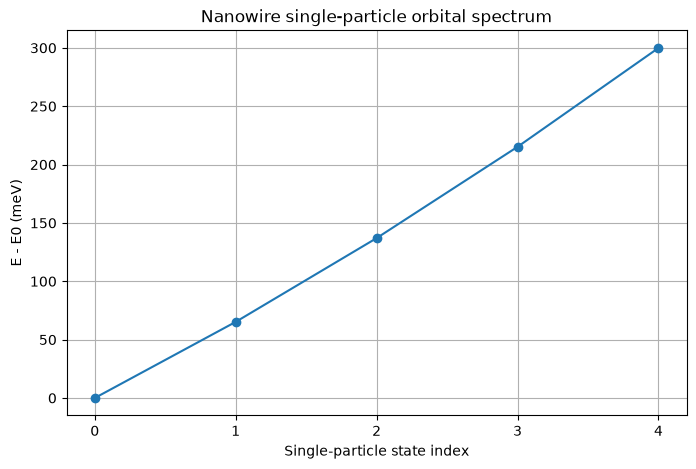

In [10]:
# [실험] Nanowire energy levels relative to E0
plt.figure(figsize=(8, 5))
plt.plot(nw_states, nw_relative_meV, marker="o")
plt.xlabel("Single-particle state index")
plt.ylabel("E - E0 (meV)")
plt.title("Nanowire single-particle orbital spectrum")
plt.grid(True)
plt.xticks(nw_states)

if SAVE_FIGURES:
    plt.savefig(EXPORT_DIR / "01_nanowire_single_particle_spectrum.png",
                dpi=180, bbox_inches="tight")
plt.show()


## 4. Nanowire HDF5 / linecut 분석

`nanowire.hdf5`에는 QTCAD가 저장한 `n`, `p`, `phi`, `EC`, `EV`가 있습니다.  
`nanowire_linecuts_z.txt`와 `nanowire_linecuts_x.txt`는 원본 코드가 각각 z축과 x축으로 저장한 `n, p, phi` linecut입니다.


In [11]:
# [동작] HDF5 tree / dataset 통계 helper
def print_hdf5_tree(group, prefix=""):
    for key, item in group.items():
        if isinstance(item, h5py.Dataset):
            print(f"{prefix}{key}  shape={item.shape}, dtype={item.dtype}")
        else:
            print(f"{prefix}{key}/")
            print_hdf5_tree(item, prefix + "  ")


def hdf5_dataset_stats(path):
    rows = []
    with h5py.File(path, "r") as f:
        def visit(name, obj):
            if isinstance(obj, h5py.Dataset) and np.issubdtype(obj.dtype, np.number):
                arr = obj[()]
                rows.append({
                    "dataset": name,
                    "shape": str(arr.shape),
                    "dtype": str(arr.dtype),
                    "min": float(np.nanmin(arr)),
                    "max": float(np.nanmax(arr)),
                    "mean": float(np.nanmean(arr)),
                    "nan_count": int(np.isnan(arr).sum()) if np.issubdtype(arr.dtype, np.floating) else 0,
                })
        f.visititems(visit)
    return pd.DataFrame(rows)

with h5py.File(FILE_NW_HDF5, "r") as f:
    print_hdf5_tree(f)

display(hdf5_dataset_stats(FILE_NW_HDF5))


EC  shape=(110040, 4), dtype=float64
EV  shape=(110040, 4), dtype=float64
n  shape=(110040, 4), dtype=float64
p  shape=(110040, 4), dtype=float64
phi  shape=(20844,), dtype=float64


,dataset,shape,dtype,min,max,mean,nan_count
0,EC,"(110040, 4)",float64,1.186316e-01,4.836897e+00,3.131113e+00,0
1,EV,"(110040, 4)",float64,-5.640000e+00,4.168966e-01,-4.274841e+00,0
2,n,"(110040, 4)",float64,4.917464e-66,2.778750e+17,6.972884e+15,0
3,p,"(110040, 4)",float64,1.981002e-76,4.991700e+20,2.128223e+19,0
4,phi,"(20844,)",float64,-9.641503e-01,5.127463e-01,5.585293e-02,0


In [12]:
# [동작] Nanowire phi 읽기 및 통계
with h5py.File(FILE_NW_HDF5, "r") as f:
    nw_phi = np.asarray(f["phi"][:], dtype=float)

nw_phi_stats_df = pd.DataFrame({
    "percentile": [0, 1, 5, 25, 50, 75, 95, 99, 100],
    "phi_V": np.percentile(nw_phi, [0, 1, 5, 25, 50, 75, 95, 99, 100]),
})

print("phi shape :", nw_phi.shape)
print("phi range :", np.min(nw_phi), "~", np.max(nw_phi), "V")
print("phi mean  :", np.mean(nw_phi), "V")
print("phi std   :", np.std(nw_phi), "V")
display(nw_phi_stats_df)


phi shape : (20844,)
phi range : -0.9641502574479874 ~ 0.5127463402238659 V
phi mean  : 0.05585293414966743 V
phi std   : 0.5770481641879445 V


,percentile,phi_V
0,0,-0.964150
1,1,-0.964150
2,5,-0.949055
3,25,-0.484912
4,50,0.408930
5,75,0.491157
6,95,0.512746
7,99,0.512746
8,100,0.512746


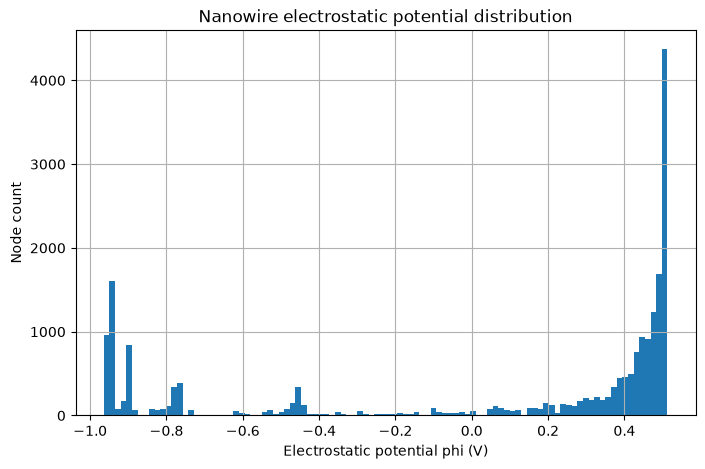

In [13]:
# [실험] Nanowire electrostatic potential distribution
plt.figure(figsize=(8, 5))
plt.hist(nw_phi, bins=100)
plt.xlabel("Electrostatic potential phi (V)")
plt.ylabel("Node count")
plt.title("Nanowire electrostatic potential distribution")
plt.grid(True)

if SAVE_FIGURES:
    plt.savefig(EXPORT_DIR / "02_nanowire_phi_histogram.png",
                dpi=180, bbox_inches="tight")
plt.show()


In [14]:
# [동작] Nanowire linecut 읽기
def load_linecut_txt(path):
    arr = np.loadtxt(path, comments="#")
    if arr.ndim == 1:
        arr = arr[None, :]
    if arr.shape[1] < 4:
        raise ValueError(f"Expected >=4 columns in {path}, got {arr.shape}")
    return pd.DataFrame(arr[:, :4], columns=["distance_nm", "n_m-3", "p_m-3", "phi_V"])

nw_line_z = load_linecut_txt(FILE_NW_LINECUT_Z)
nw_line_x = load_linecut_txt(FILE_NW_LINECUT_X)

print("z-linecut rows:", len(nw_line_z))
print("x-linecut rows:", len(nw_line_x))
display(nw_line_z.head())
display(nw_line_x.head())


z-linecut rows: 210
x-linecut rows: 152


,distance_nm,n_m-3,p_m-3,phi_V
0,0.000000,0.415622,4.991700e+26,-0.964150
1,0.128686,0.421870,4.985154e+26,-0.963783
2,0.128686,0.421870,4.985154e+26,-0.963783
3,0.651558,0.446993,4.958818e+26,-0.962304
4,0.651558,0.446993,4.958818e+26,-0.962304


,distance_nm,n_m-3,p_m-3,phi_V
0,0.000000,3.180621e-35,1.981002e-70,0.512746
1,0.061908,2.842828e-35,2.249224e-70,0.509654
2,0.061908,2.842828e-35,2.249224e-70,0.509654
3,0.119632,2.528212e-35,2.498948e-70,0.506775
4,0.119632,2.528212e-35,2.498948e-70,0.506775


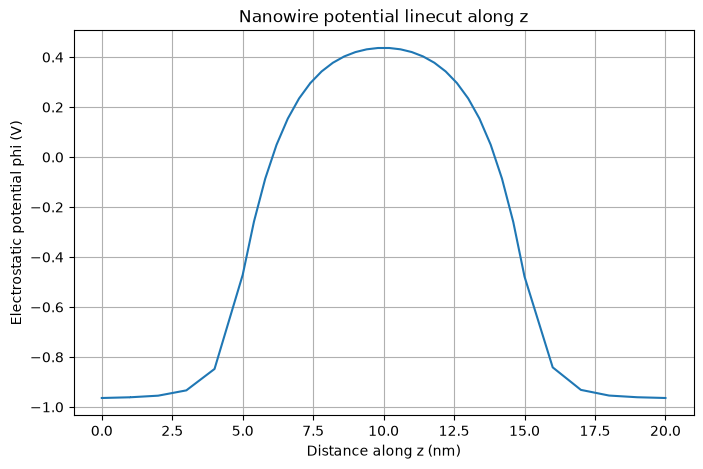

In [15]:
# [실험] z-direction potential linecut
plt.figure(figsize=(8, 5))
plt.plot(nw_line_z["distance_nm"], nw_line_z["phi_V"])
plt.xlabel("Distance along z (nm)")
plt.ylabel("Electrostatic potential phi (V)")
plt.title("Nanowire potential linecut along z")
plt.grid(True)

if SAVE_FIGURES:
    plt.savefig(EXPORT_DIR / "03_nanowire_phi_linecut_z.png",
                dpi=180, bbox_inches="tight")
plt.show()


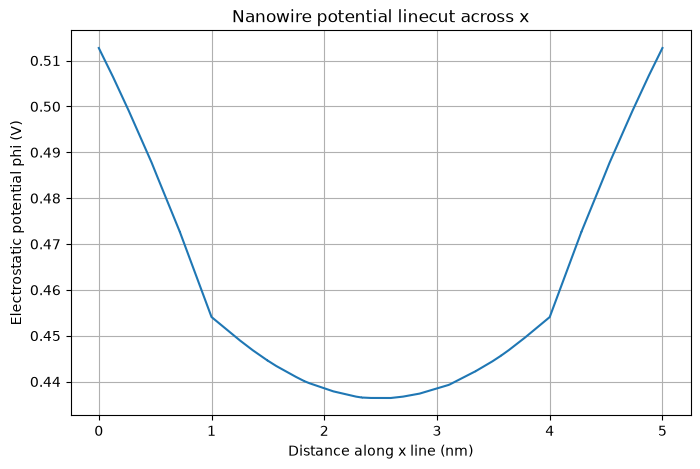

In [16]:
# [실험] x-direction potential linecut at z=L/2
plt.figure(figsize=(8, 5))
plt.plot(nw_line_x["distance_nm"], nw_line_x["phi_V"])
plt.xlabel("Distance along x line (nm)")
plt.ylabel("Electrostatic potential phi (V)")
plt.title("Nanowire potential linecut across x")
plt.grid(True)

if SAVE_FIGURES:
    plt.savefig(EXPORT_DIR / "04_nanowire_phi_linecut_x.png",
                dpi=180, bbox_inches="tight")
plt.show()


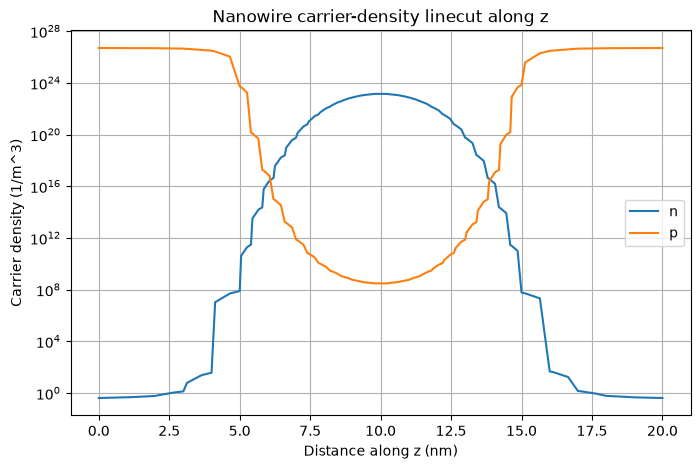

In [17]:
# [실험] z-direction carrier densities
plt.figure(figsize=(8, 5))

n_z = np.clip(nw_line_z["n_m-3"].to_numpy(), np.finfo(float).tiny, None)
p_z = np.clip(nw_line_z["p_m-3"].to_numpy(), np.finfo(float).tiny, None)

plt.semilogy(nw_line_z["distance_nm"], n_z, label="n")
plt.semilogy(nw_line_z["distance_nm"], p_z, label="p")
plt.xlabel("Distance along z (nm)")
plt.ylabel("Carrier density (1/m^3)")
plt.title("Nanowire carrier-density linecut along z")
plt.grid(True)
plt.legend()

if SAVE_FIGURES:
    plt.savefig(EXPORT_DIR / "05_nanowire_carrier_linecut_z.png",
                dpi=180, bbox_inches="tight")
plt.show()


## 5. Nanowire many-body 계산 재현 — 선택 실행

`manybody.py`는 별도의 결과 txt를 저장하지 않고 stdout / plot으로 결과를 보여줍니다.  
따라서 아래 셀은 `RUN_NANOWIRE_MANYBODY = True`로 바꿨을 때 기존 `nanowire.hdf5`의 `phi`를 읽어 **single-body → many-body** 계산을 다시 수행합니다.

기본값은 `False`입니다. 결과 분석만 할 때 불필요한 재계산을 피하기 위한 설정입니다.


**물리 모델 — Charge Addition Spectrum**: QTCAD `many_body.Solver.get_add_spectrum`
공식 문서에 명시된 정의(요동-소산 정리, grand-canonical 앙상블):
$$
\frac{\partial \langle N\rangle}{\partial \mu} = \frac{\langle N^2\rangle - \langle N\rangle^2}{k_B T}
$$
($N$=전체 입자수, $\mu$=저장소 화학퍼텐셜, $T$=온도). 이 양의 피크가 전자가 하나씩
추가될 때마다 나타나는 Coulomb blockade 피크이며, 피크 사이 간격이 addition energy
$E_\mathrm{add}(N) = \mu(N{+}1)-\mu(N)$에 해당합니다.

In [18]:
# [동작] QTCAD import 준비
try:
    from qtcad.device import constants as ct
    from qtcad.device.mesh3d import Mesh, SubMesh
    from qtcad.device import io
    from qtcad.device import analysis as qtcad_analysis
    from qtcad.device import materials as mt
    from qtcad.device import Device, SubDevice
    from qtcad.device.schrodinger import Solver as SingleBodySolver
    from qtcad.device.many_body import Solver as ManyBodySolver
    from qtcad.device.many_body import SolverParams as ManyBodySolverParams

    HAVE_QTCAD = True
    print("[OK] QTCAD import 성공")
except Exception as exc:
    HAVE_QTCAD = False
    print("[주의] QTCAD import 실패:", repr(exc))
    print("Jupyter kernel이 qtcad conda 환경인지 확인하세요.")



|  ||  |||                                                                 \\  
|  ||  |||         @@@@     @@@@@@@@      @@@@@        @       @@@@@@@      \\ 
|  ||  |||      @@@   @@@      @@      @@@    @       @@       @@    @@@     \\
|  ||  |||     @@       @@     @@     @@             @ @@      @@     @@@     \\
|  ||  |||     @@       @@     @@     @@            @    @     @@      @@     //
|  ||  |||      @@     @@      @@      @@@    @    @@@@@@@@    @@    @@@     //
|  ||  |||        @@@@@@       @@        @@@@@@   @@      @@   @@@@@@       // 
|  ||  |||             @@                                                  //   

                                 Version 2.2.6                                  
  Copyright (c) 2022-2026 Nanoacademic Technologies Inc. All rights reserved.   

      Welcome to QTCAD, the Quantum-Technology Computer-Aided Design tool.      

                        For documentation, please visit:                        
                      https:/

[OK] QTCAD import 성공


In [19]:
# [실험] manybody.py 핵심 계산 재현
nanowire_mb_results = None

if RUN_NANOWIRE_MANYBODY and HAVE_QTCAD:
    Vgs = 0.5
    Ew = mt.Si.chi + mt.Si.Eg / 2

    mesh_mb = Mesh(1e-9, str(FILE_NW_MSH))
    dvc_mb = Device(mesh_mb, conf_carriers="e")
    dvc_mb.statistics = "FD_approx"

    dvc_mb.new_region("channel_ox", mt.SiO2)
    dvc_mb.new_region("source_ox", mt.SiO2)
    dvc_mb.new_region("drain_ox", mt.SiO2)
    dvc_mb.new_region("channel", mt.Si)
    dvc_mb.new_region("source", mt.Si, pdoping=5e20 * 1e6, ndoping=0)
    dvc_mb.new_region("drain", mt.Si, pdoping=5e20 * 1e6, ndoping=0)

    dvc_mb.new_ohmic_bnd("source_bnd")
    dvc_mb.new_ohmic_bnd("drain_bnd")
    dvc_mb.new_gate_bnd("gate_bnd", Vgs, Ew)

    dvc_mb.set_potential(io.load(FILE_NW_HDF5, "phi"))

    single_solver = SingleBodySolver(dvc_mb)
    single_solver.solve()

    mb_params = ManyBodySolverParams()
    mb_params.num_states = 3
    mb_params.n_degen = 2
    mb_params.alpha = 0.5
    mb_params.num_particles = [0, 1, 2, 3]

    mb_solver = ManyBodySolver(dvc_mb, solver_params=mb_params)
    mb_solver.solve()

    # Source code가 직접 접근하는 결과만 사용
    E2_eV = np.asarray(dvc_mb.get_N_particle_subspace(2).eigval / ct.e)
    basis2 = dvc_mb.get_N_particle_subspace(2).get_bas_set(dtype="str")
    chem_eV = np.asarray(dvc_mb.chem_potentials / ct.e)
    coulomb_peaks_V = np.asarray(dvc_mb.coulomb_peak_pos)

    nanowire_mb_results = {
        "two_electron_energies_eV": E2_eV,
        "basis_N2": basis2,
        "chemical_potentials_eV": chem_eV,
        "coulomb_peak_pos_V": coulomb_peaks_V,
    }

    print("Two-electron basis size:", len(basis2))
    print("Two-electron energies (eV):")
    print(E2_eV)
    print("Chemical potentials (eV):")
    print(chem_eV)
    print("Coulomb peak positions (V):")
    print(coulomb_peaks_V)

elif RUN_NANOWIRE_MANYBODY and not HAVE_QTCAD:
    print("[주의] RUN_NANOWIRE_MANYBODY=True 이지만 QTCAD import가 되지 않았습니다.")
else:
    print("[INFO] 재계산 생략. RUN_NANOWIRE_MANYBODY=True 로 바꾸면 실행합니다.")


[INFO] 재계산 생략. RUN_NANOWIRE_MANYBODY=True 로 바꾸면 실행합니다.


## 6. Double-dot exchange 입력값과 Coulomb matrix

`exchange_1.py`는 `tunnel_coupling_low_barrier.txt`의 값을 그대로 `tunnel_coupling` 변수로 읽습니다.  
이 노트북도 **원본 코드의 convention을 그대로 재현**하여 perturbative exchange를 계산합니다.

\[
J_{\mathrm{pert}} = \frac{(t e)^2}{U_{00}}
\]

여기서 txt의 `t`는 eV, Coulomb matrix는 J 단위입니다.


In [20]:
# [동작] tunnel-coupling 입력값 단위 환산
tunnel_coupling_eV = float(np.loadtxt(FILE_TUNNEL_LOW))
tunnel_coupling_ueV = tunnel_coupling_eV * 1e6
tunnel_coupling_GHz = tunnel_coupling_eV * elementary_charge / planck_h / 1e9

print(f"Code input tunnel_coupling : {tunnel_coupling_eV:.12e} eV")
print(f"                           : {tunnel_coupling_ueV:.6f} µeV")
print(f"                           : {tunnel_coupling_GHz:.6f} GHz (E/h)")
print("\n[주의] 여기서는 exchange_1.py와 동일하게 txt 값을 그대로 t로 사용합니다.")


Code input tunnel_coupling : 2.651278645089e-04 eV
                           : 265.127865 µeV
                           : 64.107632 GHz (E/h)

[주의] 여기서는 exchange_1.py와 동일하게 txt 값을 그대로 t로 사용합니다.


In [21]:
# [동작] localized-basis Coulomb matrix
coulomb_J = np.atleast_2d(np.loadtxt(FILE_COULOMB)).astype(float)
coulomb_eV = coulomb_J / elementary_charge
coulomb_meV = coulomb_eV * 1e3

coulomb_df = pd.DataFrame(
    coulomb_meV,
    index=[f"basis_{i}" for i in range(coulomb_meV.shape[0])],
    columns=[f"basis_{i}" for i in range(coulomb_meV.shape[1])],
)

display(coulomb_df)

print("Matrix shape      :", coulomb_J.shape)
print("Symmetric?        :", np.allclose(coulomb_J, coulomb_J.T))
print("U00               :", coulomb_meV[0, 0], "meV")
if coulomb_J.shape[0] >= 2 and coulomb_J.shape[1] >= 2:
    print("U11               :", coulomb_meV[1, 1], "meV")
    print("Off-diagonal U01  :", coulomb_meV[0, 1], "meV")


,basis_0,basis_1
basis_0,17.366644,4.059703
basis_1,4.059703,16.852055


Matrix shape      : (2, 2)
Symmetric?        : True
U00               : 17.36664436641466 meV
U11               : 16.85205452666983 meV
Off-diagonal U01  : 4.059703083379002 meV


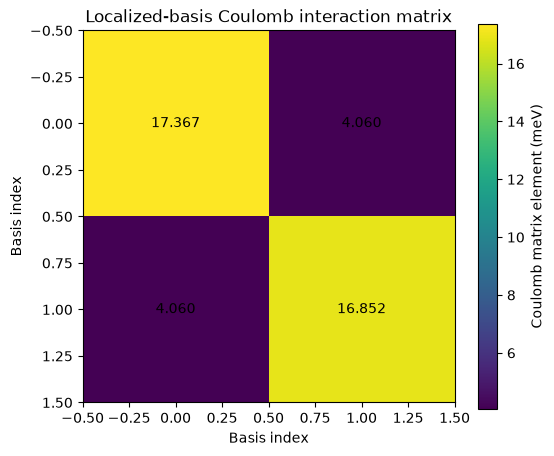

In [22]:
# [실험] Coulomb matrix heatmap
plt.figure(figsize=(6, 5))
im = plt.imshow(coulomb_meV)
plt.colorbar(im, label="Coulomb matrix element (meV)")
plt.xlabel("Basis index")
plt.ylabel("Basis index")
plt.title("Localized-basis Coulomb interaction matrix")

for i in range(coulomb_meV.shape[0]):
    for j in range(coulomb_meV.shape[1]):
        plt.text(j, i, f"{coulomb_meV[i, j]:.3f}", ha="center", va="center")

if SAVE_FIGURES:
    plt.savefig(EXPORT_DIR / "06_exchange_coulomb_matrix.png",
                dpi=180, bbox_inches="tight")
plt.show()


## 7. Perturbation theory exchange coupling

저장된 `exchange_perturbation.txt`와 원본 식으로 다시 계산한 값을 비교하여 output consistency를 확인합니다.


In [23]:
# [점검] perturbative exchange 재계산
J_pert_saved_J = float(np.loadtxt(FILE_J_PERT))
J_pert_calc_J = (tunnel_coupling_eV * elementary_charge) ** 2 / coulomb_J[0, 0]

J_pert_saved_eV = J_pert_saved_J / elementary_charge
J_pert_saved_ueV = J_pert_saved_eV * 1e6
J_pert_saved_MHz = J_pert_saved_J / planck_h / 1e6

relative_formula_error = abs(J_pert_calc_J - J_pert_saved_J) / abs(J_pert_saved_J)

print(f"Saved J_pert      : {J_pert_saved_J:.12e} J")
print(f"                  : {J_pert_saved_ueV:.6f} µeV")
print(f"                  : {J_pert_saved_MHz:.6f} MHz")
print(f"Recomputed J_pert : {J_pert_calc_J:.12e} J")
print(f"Formula mismatch  : {relative_formula_error:.3e} (relative)")

if relative_formula_error < 1e-6:
    print("[OK] exchange_1.py의 저장값과 식 재계산이 일치합니다.")
else:
    print("[주의] 저장값과 재계산값 차이가 예상보다 큽니다.")


Saved J_pert      : 6.484928958233e-25 J
                  : 4.047574 µeV
                  : 978.699110 MHz
Recomputed J_pert : 6.484929071565e-25 J
Formula mismatch  : 1.748e-08 (relative)
[OK] exchange_1.py의 저장값과 식 재계산이 일치합니다.


## 8. Exact diagonalization — two-electron spectrum

`exchange_2.py`는 `num_states = 8`, `n_degen = 2`, `num_particles = [2]`로 many-body Hamiltonian을 풉니다.

따라서 spin-degenerate single-particle orbital 수는 16개이고, 두 전자를 배치하는 Slater basis의 최대 크기는

\[
\binom{16}{2}=120
\]

입니다. 저장된 two-electron energy 개수와 이 값을 비교합니다.


**물리 모델 — Exact Diagonalization**: 2차 양자화 Hamiltonian
$$
\hat{H} = \sum_{ij\sigma} h_{ij}\, c_{i\sigma}^\dagger c_{j\sigma}
+ \frac{1}{2}\sum_{ijkl,\sigma\sigma'} V_{ijkl}\, c_{i\sigma}^\dagger c_{j\sigma'}^\dagger c_{k\sigma'} c_{l\sigma}
$$
($h_{ij}$=단일입자 Hamiltonian 행렬요소, $V_{ijkl}$=Coulomb 적분)을 두 전자(Slater
행렬식) 부분공간에서 **그대로 대각화**합니다 — M16의 2차 섭동론과 달리 근사 없이
모든 가상전이를 포함하므로, 더 정확하지만 기저 크기(아래 조합수)에 따라 계산 비용이
빠르게 커집니다.

In [24]:
# [동작] exact two-electron energies 읽기
two_e_eV = np.atleast_1d(np.loadtxt(FILE_TWO_E)).astype(float)
two_e_rel_ueV = (two_e_eV - two_e_eV[0]) * 1e6

expected_spin_orbitals = 8 * 2
expected_two_e_dim = comb(expected_spin_orbitals, 2)

print("Saved energy count          :", len(two_e_eV))
print("Expected C(16,2) dimension  :", expected_two_e_dim)
print("Dimension match             :", len(two_e_eV) == expected_two_e_dim)

n_show = min(12, len(two_e_eV))
two_e_table = pd.DataFrame({
    "state": np.arange(n_show),
    "energy_eV": two_e_eV[:n_show],
    "E_minus_E0_ueV": two_e_rel_ueV[:n_show],
})
display(two_e_table)


Saved energy count          : 120
Expected C(16,2) dimension  : 120
Dimension match             : True


,state,energy_eV,E_minus_E0_ueV
0,0,0.090838,0.000000
1,1,0.090841,2.421863
2,2,0.090841,2.421863
3,3,0.090841,2.421863
4,4,0.095579,4740.488173
5,5,0.095579,4740.488173
6,6,0.095579,4740.488173
7,7,0.095587,4749.127697
8,8,0.095951,5113.040920
9,9,0.095951,5113.040920


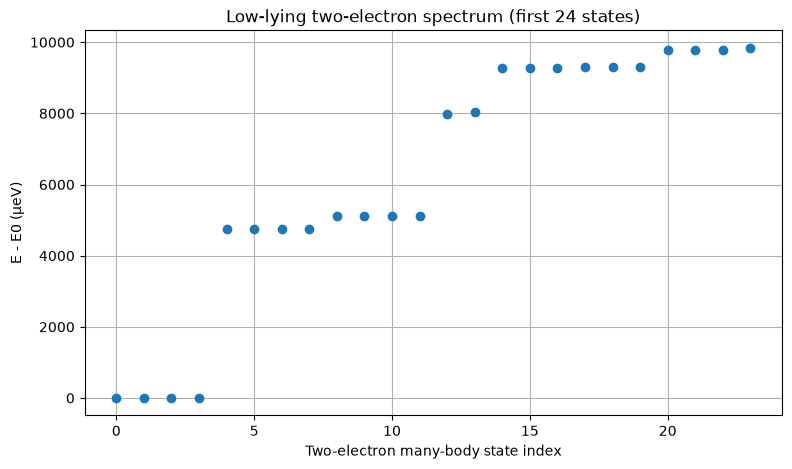

In [25]:
# [실험] Low-lying two-electron spectrum
n_plot = min(24, len(two_e_eV))
plt.figure(figsize=(9, 5))
plt.plot(np.arange(n_plot), two_e_rel_ueV[:n_plot], marker="o", linestyle="none")
plt.xlabel("Two-electron many-body state index")
plt.ylabel("E - E0 (µeV)")
plt.title(f"Low-lying two-electron spectrum (first {n_plot} states)")
plt.grid(True)

if SAVE_FIGURES:
    plt.savefig(EXPORT_DIR / "07_two_electron_low_energy_spectrum.png",
                dpi=180, bbox_inches="tight")
plt.show()


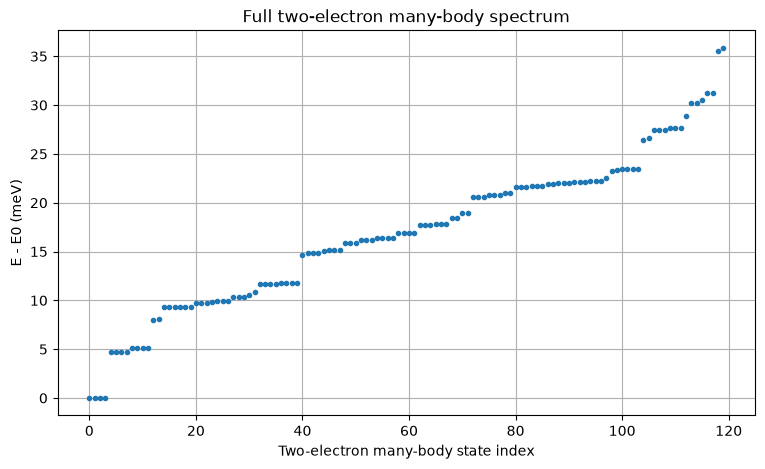

In [26]:
# [실험] Full two-electron spectrum relative to ground state
plt.figure(figsize=(9, 5))
plt.plot(np.arange(len(two_e_eV)), (two_e_eV - two_e_eV[0]) * 1e3,
         marker=".", linestyle="none")
plt.xlabel("Two-electron many-body state index")
plt.ylabel("E - E0 (meV)")
plt.title("Full two-electron many-body spectrum")
plt.grid(True)

if SAVE_FIGURES:
    plt.savefig(EXPORT_DIR / "08_two_electron_full_spectrum.png",
                dpi=180, bbox_inches="tight")
plt.show()


## 9. Exact exchange vs perturbation theory

원본 `exchange_2.py`와 동일하게

\[
J_{\mathrm{exact}} = E_1-E_0
\]

으로 정의하고 MHz로 환산합니다.


In [27]:
# [동작] exact exchange 및 perturbative 값 비교
J_exact_eV = two_e_eV[1] - two_e_eV[0]
J_exact_J = J_exact_eV * elementary_charge
J_exact_ueV = J_exact_eV * 1e6
J_exact_MHz = J_exact_J / planck_h / 1e6

exact_over_pert = J_exact_J / J_pert_saved_J
pert_over_exact = J_pert_saved_J / J_exact_J
relative_difference_vs_exact = abs(J_pert_saved_J - J_exact_J) / abs(J_exact_J)

exchange_compare_df = pd.DataFrame([
    {
        "method": "Perturbation theory",
        "J_ueV": J_pert_saved_ueV,
        "J_MHz": J_pert_saved_MHz,
    },
    {
        "method": "Exact diagonalization",
        "J_ueV": J_exact_ueV,
        "J_MHz": J_exact_MHz,
    },
])

display(exchange_compare_df)

print(f"Exact / perturbative         : {exact_over_pert:.6f}")
print(f"Perturbative / exact         : {pert_over_exact:.6f}")
print(f"|Pert - Exact| / Exact       : {relative_difference_vs_exact*100:.3f} %")

exchange_compare_csv = EXPORT_DIR / "exchange_comparison.csv"
exchange_compare_df.to_csv(exchange_compare_csv, index=False)
print("Saved:", exchange_compare_csv)


,method,J_ueV,J_MHz
0,Perturbation theory,4.047574,978.699110
1,Exact diagonalization,2.421863,585.603884


Exact / perturbative         : 0.598349
Perturbative / exact         : 1.671265
|Pert - Exact| / Exact       : 67.126 %
Saved: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M05. Many-body\Reference\analysis_exports_M05\exchange_comparison.csv


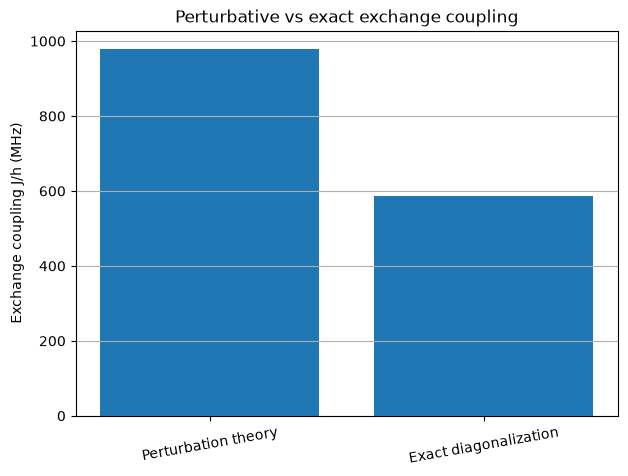

In [28]:
# [실험] Exchange coupling comparison
plt.figure(figsize=(7, 5))
plt.bar(exchange_compare_df["method"], exchange_compare_df["J_MHz"])
plt.ylabel("Exchange coupling J/h (MHz)")
plt.title("Perturbative vs exact exchange coupling")
plt.grid(True, axis="y")
plt.xticks(rotation=10)

if SAVE_FIGURES:
    plt.savefig(EXPORT_DIR / "09_exchange_perturbative_vs_exact.png",
                dpi=180, bbox_inches="tight")
plt.show()


## 10. Detuning 전후 electrostatic potential 비교

`exchange_1.py`는 P2를 5 mV detune한 뒤 Poisson을 다시 풀고 `detuned_potential.hdf5`를 저장합니다.  
QTCAD HDF5 내부 dataset 이름은 저장 방식에 따라 `phi` 또는 `var`처럼 보일 수 있으므로, 아래에서는 1D numeric dataset을 안전하게 탐색합니다.


In [29]:
# [동작] HDF5에서 node-wise 1D array를 안전하게 읽는 helper
def load_primary_1d_numeric_dataset(path, preferred_names=("phi", "var")):
    with h5py.File(path, "r") as f:
        for name in preferred_names:
            if name in f and isinstance(f[name], h5py.Dataset):
                arr = np.asarray(f[name][:])
                if arr.ndim == 1 and np.issubdtype(arr.dtype, np.number):
                    return name, arr.astype(float)

        candidates = []
        def visit(name, obj):
            if isinstance(obj, h5py.Dataset):
                if obj.ndim == 1 and np.issubdtype(obj.dtype, np.number):
                    candidates.append(name)
        f.visititems(visit)

        if len(candidates) == 1:
            name = candidates[0]
            return name, np.asarray(f[name][:], dtype=float)
        if not candidates:
            raise KeyError(f"No 1D numeric dataset found in {path}")
        raise KeyError(f"Multiple 1D numeric datasets found in {path}: {candidates}")

ref_phi_key, dqd_phi_ref = load_primary_1d_numeric_dataset(FILE_TUNNEL_PHI)
det_phi_key, dqd_phi_det = load_primary_1d_numeric_dataset(FILE_DETUNED_PHI)

print("Reference potential dataset:", ref_phi_key, dqd_phi_ref.shape)
print("Detuned potential dataset  :", det_phi_key, dqd_phi_det.shape)

assert dqd_phi_ref.shape == dqd_phi_det.shape, "Reference/detuned phi shape mismatch"
print("[OK] 두 potential 배열의 shape가 같습니다.")


Reference potential dataset: phi (173626,)
Detuned potential dataset  : var (173626,)
[OK] 두 potential 배열의 shape가 같습니다.


In [30]:
# [동작] Detuning-induced delta phi 통계
delta_phi = dqd_phi_det - dqd_phi_ref

potential_compare_df = pd.DataFrame({
    "quantity": ["reference_phi", "detuned_phi", "delta_phi"],
    "min_V": [dqd_phi_ref.min(), dqd_phi_det.min(), delta_phi.min()],
    "max_V": [dqd_phi_ref.max(), dqd_phi_det.max(), delta_phi.max()],
    "mean_V": [dqd_phi_ref.mean(), dqd_phi_det.mean(), delta_phi.mean()],
    "std_V": [dqd_phi_ref.std(), dqd_phi_det.std(), delta_phi.std()],
    "rms_V": [
        np.sqrt(np.mean(dqd_phi_ref**2)),
        np.sqrt(np.mean(dqd_phi_det**2)),
        np.sqrt(np.mean(delta_phi**2)),
    ],
})

display(potential_compare_df)

print("delta phi percentiles [V]")
for q, value in zip(
    [0, 1, 5, 25, 50, 75, 95, 99, 100],
    np.percentile(delta_phi, [0, 1, 5, 25, 50, 75, 95, 99, 100])
):
    print(f"{q:>3}% : {value:+.9e}")


,quantity,min_V,max_V,mean_V,std_V,rms_V
0,reference_phi,0.037005,0.642937,0.366411,0.167394,0.402837
1,detuned_phi,0.037009,0.642941,0.374056,0.170751,0.411186
2,delta_phi,-0.000038,0.060004,0.007645,0.011786,0.014048


delta phi percentiles [V]
  0% : -3.814329945e-05
  1% : +4.007144454e-06
  5% : +4.007144454e-06
 25% : +4.579580397e-04
 50% : +2.626667445e-03
 75% : +9.148834658e-03
 95% : +3.396819339e-02
 99% : +5.676839749e-02
100% : +6.000400714e-02


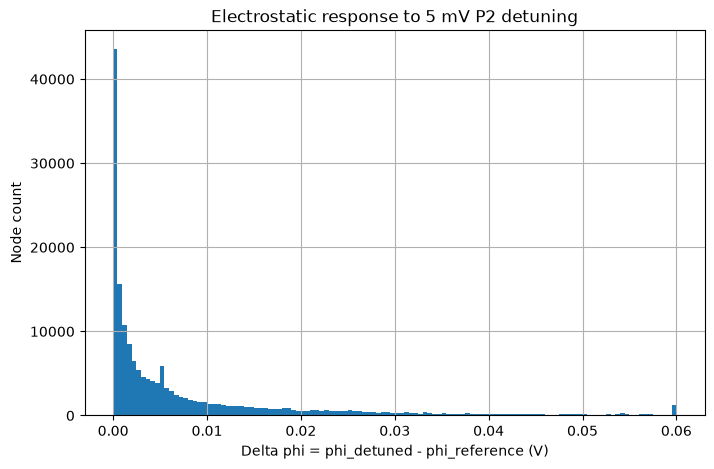

In [31]:
# [실험] Detuning-induced potential change distribution
plt.figure(figsize=(8, 5))
plt.hist(delta_phi, bins=120)
plt.xlabel("Delta phi = phi_detuned - phi_reference (V)")
plt.ylabel("Node count")
plt.title("Electrostatic response to 5 mV P2 detuning")
plt.grid(True)

if SAVE_FIGURES:
    plt.savefig(EXPORT_DIR / "10_detuning_delta_phi_histogram.png",
                dpi=180, bbox_inches="tight")
plt.show()


In [32]:
# [점검] refined mesh node 수와 potential vector 길이 일치 여부
refined_nodes_from_header = int(ref_counts["nodes"])

print("Refined mesh nodes      :", refined_nodes_from_header)
print("Reference phi length    :", len(dqd_phi_ref))
print("Detuned phi length      :", len(dqd_phi_det))

if len(dqd_phi_ref) == refined_nodes_from_header == len(dqd_phi_det):
    print("[OK] node-wise potential ↔ refined mesh node count가 일치합니다.")
else:
    print("[주의] mesh node 수와 potential 길이를 다시 확인하세요.")


Refined mesh nodes      : 173626
Reference phi length    : 173626
Detuned phi length      : 173626
[OK] node-wise potential ↔ refined mesh node count가 일치합니다.


## 11. QTCAD mesh + potential linecut — QTCAD 환경에서 실행

QTCAD import가 가능하면 refined mesh에 node-wise potential을 결합하여 channel 방향 linecut을 봅니다.


Loading mesh from file:
 C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M05. Many-body\Reference\meshes\refined_dqdfdsoi.msh


Done.
3D MESH STATISTICS
--------------------------------------------------------------------------------
Total number of elements      1022018             
Triangular elements           31435               
Tetrahedral elements          990583              
Total number of nodes         173626              
Boundary physical names       barrier_gate_1_bnd, plunger_gate_1_bnd, barrier_gate_2_bnd, plunger_gate_2_bnd, barrier_gate_3_bnd, source_bnd, drain_bnd, back_gate_bnd, 
Region physical names         gate_oxide_dot, gate_oxide, source, drain, channel, oxide, channel_dot, oxide_dot, buried_oxide, buried_oxide_dot, 


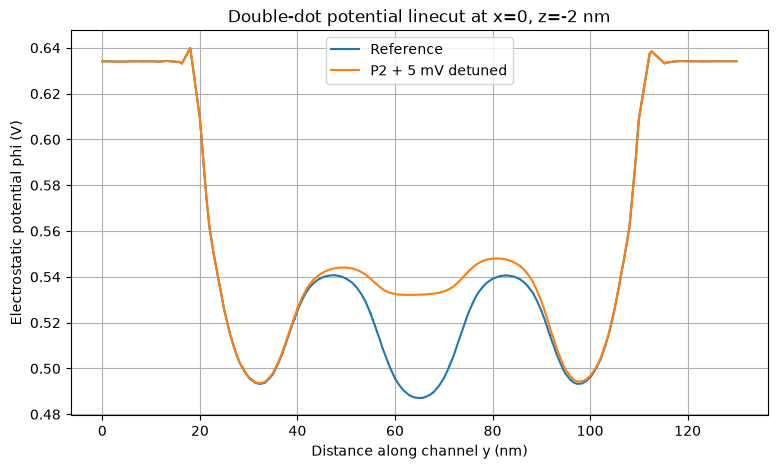

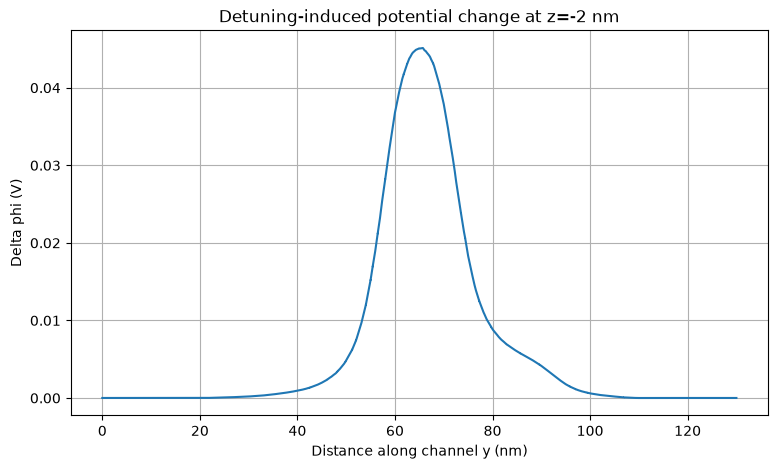

In [33]:
# [실험] Reference / detuned / delta potential channel-direction linecut
if HAVE_QTCAD:
    mesh_dqd = Mesh(1e-9, str(FILE_DQD_REFINED_MSH))
    xyz = mesh_dqd.glob_nodes

    if len(xyz) != len(dqd_phi_ref):
        raise ValueError(
            f"Mesh nodes ({len(xyz)}) != phi values ({len(dqd_phi_ref)})"
        )

    ymin = float(np.min(xyz[:, 1]))
    ymax = float(np.max(xyz[:, 1]))

    distance_y, phi_ref_line = qtcad_analysis.linecut(
        mesh_dqd,
        dqd_phi_ref,
        (0.0, ymin, Z_DQD_SLICE_NM * 1e-9),
        (0.0, ymax, Z_DQD_SLICE_NM * 1e-9),
    )
    _, phi_det_line = qtcad_analysis.linecut(
        mesh_dqd,
        dqd_phi_det,
        (0.0, ymin, Z_DQD_SLICE_NM * 1e-9),
        (0.0, ymax, Z_DQD_SLICE_NM * 1e-9),
    )

    plt.figure(figsize=(9, 5))
    plt.plot(distance_y / 1e-9, phi_ref_line, label="Reference")
    plt.plot(distance_y / 1e-9, phi_det_line, label="P2 + 5 mV detuned")
    plt.xlabel("Distance along channel y (nm)")
    plt.ylabel("Electrostatic potential phi (V)")
    plt.title(f"Double-dot potential linecut at x=0, z={Z_DQD_SLICE_NM:g} nm")
    plt.grid(True)
    plt.legend()

    if SAVE_FIGURES:
        plt.savefig(EXPORT_DIR / "11_dqd_reference_vs_detuned_phi_linecut.png",
                    dpi=180, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.plot(distance_y / 1e-9, phi_det_line - phi_ref_line)
    plt.xlabel("Distance along channel y (nm)")
    plt.ylabel("Delta phi (V)")
    plt.title(f"Detuning-induced potential change at z={Z_DQD_SLICE_NM:g} nm")
    plt.grid(True)

    if SAVE_FIGURES:
        plt.savefig(EXPORT_DIR / "12_dqd_delta_phi_linecut.png",
                    dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("[INFO] QTCAD import가 되지 않아 mesh linecut을 건너뜁니다.")


## 12. Localized wavefunction VTU 분석

`exchange_localized_wavefunctions.vtu`에는 `exchange_1.py`가 저장한 `Ground state`, `First excited state`가 들어 있습니다.

파일이 크므로 한 번만 읽고 다음을 추출합니다.
- point / cell 수, bounds, field 이름
- 각 wavefunction의 최대 절대진폭 위치
- `z = Z_DQD_SLICE_NM` 근방의 \(|\psi|^2\) slice
- `x=0`, 같은 z에서 channel-y 방향 raw amplitude / probability profile

> unstructured mesh의 point sample을 단순 합산한 값은 체적 적분과 같지 않으므로, 여기서는 peak와 profile 위주로 분석합니다.


In [34]:
# [동작] PyVista 준비
try:
    import pyvista as pv
    HAVE_PYVISTA = True
    print("[OK] PyVista import 성공:", pv.__version__)
except Exception as exc:
    HAVE_PYVISTA = False
    print("[주의] PyVista import 실패:", repr(exc))
    print("필요하면 qtcad 환경에서 pyvista 설치 여부를 확인하세요.")


[OK] PyVista import 성공: 0.49.0


In [35]:
# [동작] Localized wavefunction VTU 분석 함수
def analyze_exchange_wavefunction_vtu(vtu_path, z_slice_nm=-2.0, line_resolution=600):
    if not HAVE_PYVISTA:
        return None

    grid = pv.read(vtu_path)

    print("Points :", f"{grid.n_points:,}")
    print("Cells  :", f"{grid.n_cells:,}")
    print("Bounds :", grid.bounds)
    print("Point-data arrays:", list(grid.point_data.keys()))

    required = ["Ground state", "First excited state"]
    for name in required:
        if name not in grid.point_data:
            raise KeyError(f"{name!r}가 VTU point_data에 없습니다.")

    metrics = []
    for state_name in required:
        psi = np.asarray(grid.point_data[state_name])
        idx_peak = int(np.argmax(np.abs(psi)))
        peak_xyz = grid.points[idx_peak]

        metrics.append({
            "state": state_name,
            "psi_min": float(np.min(psi)),
            "psi_max": float(np.max(psi)),
            "max_abs_psi": float(np.max(np.abs(psi))),
            "peak_x_nm": float(peak_xyz[0]),
            "peak_y_nm": float(peak_xyz[1]),
            "peak_z_nm": float(peak_xyz[2]),
        })

    # Plane slice. QTCAD VTU coordinates in this example are nm.
    sliced = grid.slice(normal=(0, 0, 1), origin=(0, 0, z_slice_nm))
    slice_data = {}
    for state_name in required:
        psi = np.asarray(sliced.point_data[state_name])
        prob = np.abs(psi) ** 2
        m = np.max(prob) if len(prob) else 0.0
        slice_data[state_name] = {
            "points": np.asarray(sliced.points),
            "prob_norm": prob / m if m > 0 else prob,
        }

    # channel-direction line: x=0, z=z_slice_nm
    bounds = grid.bounds
    p0 = (0.0, bounds[2], z_slice_nm)
    p1 = (0.0, bounds[3], z_slice_nm)
    line = grid.sample_over_line(p0, p1, resolution=line_resolution)

    line_data = {
        "y_nm": np.asarray(line.points[:, 1]),
    }
    for state_name in required:
        line_data[state_name] = np.asarray(line.point_data[state_name])

    return {
        "grid": grid,
        "metrics": metrics,
        "slice": slice_data,
        "line": line_data,
    }


In [36]:
# [동작] VTU 실제 분석
exchange_wf = None

if HAVE_PYVISTA and ANALYZE_LARGE_VTU and FILE_EXCHANGE_WF.exists():
    exchange_wf = analyze_exchange_wavefunction_vtu(
        FILE_EXCHANGE_WF,
        z_slice_nm=Z_DQD_SLICE_NM,
        line_resolution=LINE_RESOLUTION,
    )

    wf_metrics_df = pd.DataFrame(exchange_wf["metrics"])
    display(wf_metrics_df)
    wf_metrics_df.to_csv(EXPORT_DIR / "exchange_wavefunction_peak_metrics.csv", index=False)
elif not ANALYZE_LARGE_VTU:
    print("[INFO] ANALYZE_LARGE_VTU=False 이므로 129 MB급 VTU 로드를 생략합니다.")
else:
    print("[INFO] PyVista 또는 VTU 파일을 확인하세요.")


Points : 3,714,972
Cells  : 928,743
Bounds : BoundsTuple(x_min = -30.000000000000004,
            x_max =  30.000000000000004,
            y_min = -40.0,
            y_max =  40.0,
            z_min = -20.0,
            z_max =   2.0)
Point-data arrays: ['Ground state', 'First excited state']


,state,psi_min,psi_max,max_abs_psi,peak_x_nm,peak_y_nm,peak_z_nm
0,Ground state,-5.588547e+10,1.454496e+12,1.454496e+12,-2.059678,15.644342,-1.872545
1,First excited state,-7.646798e+10,1.422865e+12,1.422865e+12,-1.362432,-15.532072,-1.997804


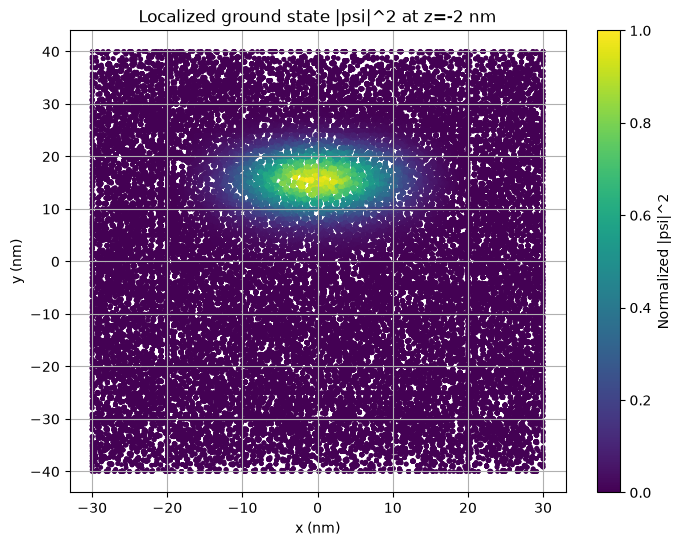

In [37]:
# [실험] Ground-state |psi|^2 slice
if exchange_wf is not None:
    state_name = "Ground state"
    pts = exchange_wf["slice"][state_name]["points"]
    vals = exchange_wf["slice"][state_name]["prob_norm"]

    if len(vals) > 100000:
        step = int(np.ceil(len(vals) / 100000))
        pts = pts[::step]
        vals = vals[::step]

    plt.figure(figsize=(8, 6))
    sc = plt.scatter(pts[:, 0], pts[:, 1], c=vals, s=6)
    plt.xlabel("x (nm)")
    plt.ylabel("y (nm)")
    plt.title(f"Localized ground state |psi|^2 at z={Z_DQD_SLICE_NM:g} nm")
    plt.colorbar(sc, label="Normalized |psi|^2")
    plt.grid(True)

    if SAVE_FIGURES:
        plt.savefig(EXPORT_DIR / "13_exchange_ground_probability_slice.png",
                    dpi=180, bbox_inches="tight")
    plt.show()


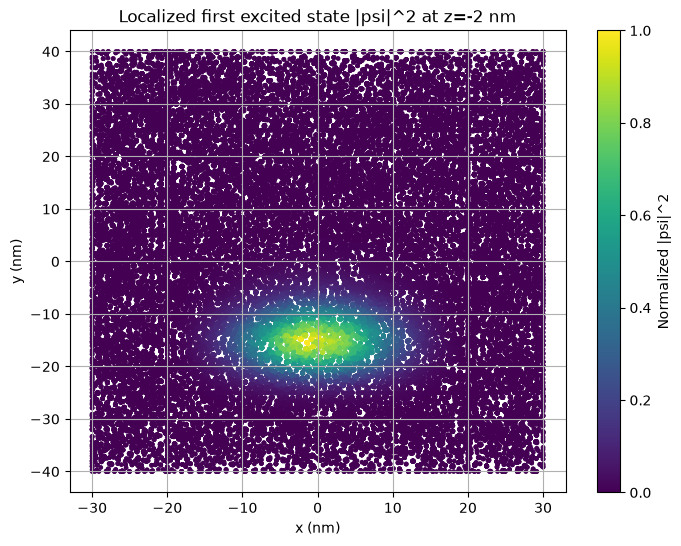

In [38]:
# [실험] First-excited-state |psi|^2 slice
if exchange_wf is not None:
    state_name = "First excited state"
    pts = exchange_wf["slice"][state_name]["points"]
    vals = exchange_wf["slice"][state_name]["prob_norm"]

    if len(vals) > 100000:
        step = int(np.ceil(len(vals) / 100000))
        pts = pts[::step]
        vals = vals[::step]

    plt.figure(figsize=(8, 6))
    sc = plt.scatter(pts[:, 0], pts[:, 1], c=vals, s=6)
    plt.xlabel("x (nm)")
    plt.ylabel("y (nm)")
    plt.title(f"Localized first excited state |psi|^2 at z={Z_DQD_SLICE_NM:g} nm")
    plt.colorbar(sc, label="Normalized |psi|^2")
    plt.grid(True)

    if SAVE_FIGURES:
        plt.savefig(EXPORT_DIR / "14_exchange_first_excited_probability_slice.png",
                    dpi=180, bbox_inches="tight")
    plt.show()


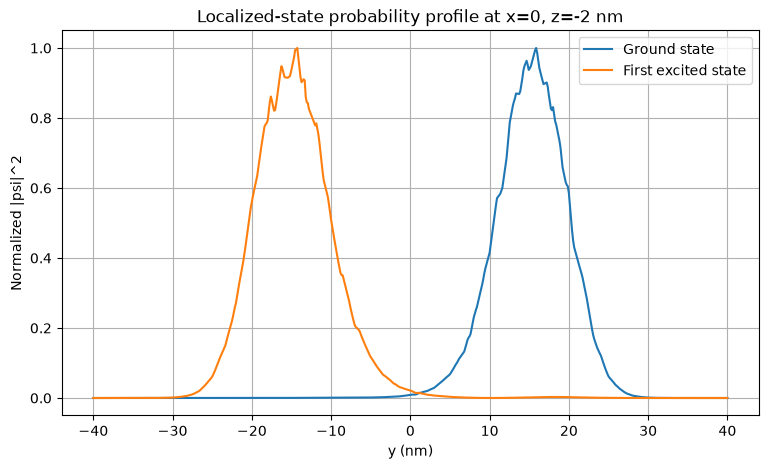

In [39]:
# [실험] Channel-direction normalized probability profiles
if exchange_wf is not None:
    y = exchange_wf["line"]["y_nm"]

    plt.figure(figsize=(9, 5))
    for state_name in ["Ground state", "First excited state"]:
        psi = exchange_wf["line"][state_name]
        prob = np.abs(psi) ** 2
        m = np.max(prob)
        prob_norm = prob / m if m > 0 else prob
        plt.plot(y, prob_norm, label=state_name)

    plt.xlabel("y (nm)")
    plt.ylabel("Normalized |psi|^2")
    plt.title(f"Localized-state probability profile at x=0, z={Z_DQD_SLICE_NM:g} nm")
    plt.grid(True)
    plt.legend()

    if SAVE_FIGURES:
        plt.savefig(EXPORT_DIR / "15_exchange_wavefunction_probability_profile.png",
                    dpi=180, bbox_inches="tight")
    plt.show()


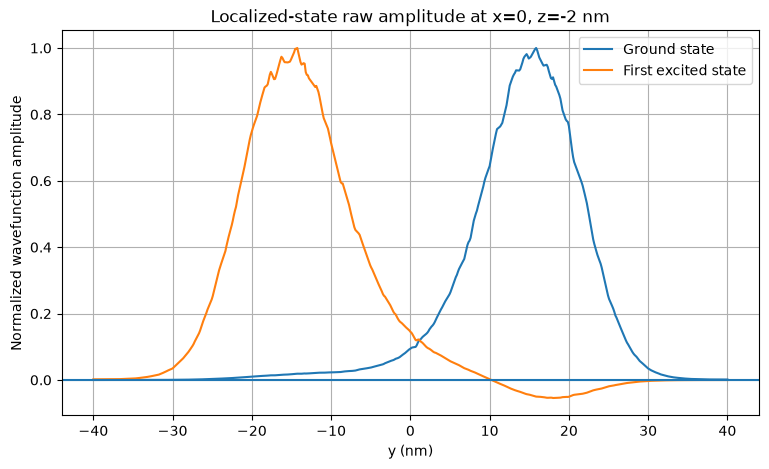

In [40]:
# [실험] Raw wavefunction sign profile
if exchange_wf is not None:
    y = exchange_wf["line"]["y_nm"]

    plt.figure(figsize=(9, 5))
    for state_name in ["Ground state", "First excited state"]:
        psi = exchange_wf["line"][state_name]
        m = np.max(np.abs(psi))
        psi_norm = psi / m if m > 0 else psi
        plt.plot(y, psi_norm, label=state_name)

    plt.axhline(0)
    plt.xlabel("y (nm)")
    plt.ylabel("Normalized wavefunction amplitude")
    plt.title(f"Localized-state raw amplitude at x=0, z={Z_DQD_SLICE_NM:g} nm")
    plt.grid(True)
    plt.legend()

    if SAVE_FIGURES:
        plt.savefig(EXPORT_DIR / "16_exchange_wavefunction_raw_profile.png",
                    dpi=180, bbox_inches="tight")
    plt.show()


In [41]:
# [동작] 대형 VTU 메모리 정리
if exchange_wf is not None:
    # metrics는 CSV로 이미 저장됨. 이후 셀에서는 grid가 필요하지 않음.
    try:
        exchange_wf["grid"] = None
    except Exception:
        pass
    gc.collect()
    print("[OK] 대형 VTU grid 참조를 해제했습니다.")


[OK] 대형 VTU grid 참조를 해제했습니다.


## 13. 핵심 수치 자동 export


In [42]:
# [동작] 핵심 scalar 결과를 한 표로 저장
summary_metrics = pd.DataFrame([
    {"metric": "nanowire_E0_eV", "value": float(nw_energies_eV[0]), "unit": "eV"},
    {"metric": "nanowire_E1_eV", "value": float(nw_energies_eV[1]), "unit": "eV"},
    {"metric": "tunnel_coupling_input", "value": tunnel_coupling_ueV, "unit": "µeV"},
    {"metric": "coulomb_U00", "value": float(coulomb_meV[0, 0]), "unit": "meV"},
    {"metric": "J_perturbative", "value": J_pert_saved_ueV, "unit": "µeV"},
    {"metric": "J_perturbative_over_h", "value": J_pert_saved_MHz, "unit": "MHz"},
    {"metric": "J_exact", "value": J_exact_ueV, "unit": "µeV"},
    {"metric": "J_exact_over_h", "value": J_exact_MHz, "unit": "MHz"},
    {"metric": "exact_over_perturbative", "value": exact_over_pert, "unit": "ratio"},
    {"metric": "potential_delta_rms", "value": float(np.sqrt(np.mean(delta_phi**2))), "unit": "V"},
    {"metric": "potential_delta_max_abs", "value": float(np.max(np.abs(delta_phi))), "unit": "V"},
    {"metric": "two_electron_spectrum_size", "value": int(len(two_e_eV)), "unit": "states"},
])

display(summary_metrics)

summary_csv = EXPORT_DIR / "M05_manybody_summary_metrics.csv"
summary_metrics.to_csv(summary_csv, index=False)
print("Saved:", summary_csv)


,metric,value,unit
0,nanowire_E0_eV,0.547980,eV
1,nanowire_E1_eV,0.613200,eV
2,tunnel_coupling_input,265.127865,µeV
3,coulomb_U00,17.366644,meV
4,J_perturbative,4.047574,µeV
5,J_perturbative_over_h,978.699110,MHz
6,J_exact,2.421863,µeV
7,J_exact_over_h,585.603884,MHz
8,exact_over_perturbative,0.598349,ratio
9,potential_delta_rms,0.014048,V


Saved: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M05. Many-body\Reference\analysis_exports_M05\M05_manybody_summary_metrics.csv


## 14. 최종 요약


In [43]:
# [점검] 핵심 결과 요약
print("=" * 92)
print("QTCAD M05 MANY-BODY — FULL ANALYSIS SUMMARY")
print("=" * 92)

print(f"Nanowire states saved            : {len(nw_energies_eV)}")
print(f"Nanowire E0                     : {nw_energies_eV[0]:.9f} eV")
print(f"Nanowire E1-E0                  : {(nw_energies_eV[1]-nw_energies_eV[0])*1e3:.6f} meV")
print(f"Refined DQD mesh nodes          : {int(ref_counts['nodes']):,}")
print(f"Refined DQD mesh elements       : {int(ref_counts['elements']):,}")
print(f"Tunnel-coupling input           : {tunnel_coupling_ueV:.6f} µeV")
print(f"Coulomb U00                     : {coulomb_meV[0,0]:.6f} meV")
print(f"Perturbative exchange J/h       : {J_pert_saved_MHz:.6f} MHz")
print(f"Exact exchange J/h              : {J_exact_MHz:.6f} MHz")
print(f"Exact / perturbative            : {exact_over_pert:.6f}")
print(f"Two-electron spectrum size      : {len(two_e_eV)} states")
print(f"Expected C(16,2)                : {expected_two_e_dim} states")
print(f"Detuning delta-phi RMS          : {np.sqrt(np.mean(delta_phi**2)):.9e} V")
print(f"Detuning max |delta-phi|        : {np.max(np.abs(delta_phi)):.9e} V")
print(f"Analysis export directory       : {EXPORT_DIR}")
print("=" * 92)


QTCAD M05 MANY-BODY — FULL ANALYSIS SUMMARY
Nanowire states saved            : 5
Nanowire E0                     : 0.547980179 eV
Nanowire E1-E0                  : 65.220041 meV
Refined DQD mesh nodes          : 173,626
Refined DQD mesh elements       : 1,022,018
Tunnel-coupling input           : 265.127865 µeV
Coulomb U00                     : 17.366644 meV
Perturbative exchange J/h       : 978.699110 MHz
Exact exchange J/h              : 585.603884 MHz
Exact / perturbative            : 0.598349
Two-electron spectrum size      : 120 states
Expected C(16,2)                : 120 states
Detuning delta-phi RMS          : 1.404843301e-02 V
Detuning max |delta-phi|        : 6.000400714e-02 V
Analysis export directory       : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M05. Many-body\Reference\analysis_exports_M05


## 해석 주의사항

- `tunnel_coupling_low_barrier.txt`의 값은 `exchange_1.py`에서 **그대로** `tunnel_coupling`로 사용됩니다. 일반적인 2-level convention에서 `E1-E0 = 2 t_c`를 사용하는 경우와 혼동하지 말고, 이 notebook의 perturbative 재계산은 원본 코드 convention을 그대로 따릅니다.
- `exchange_coulomb_localized.txt`는 J 단위로 저장된 Coulomb matrix입니다. 표와 그림에서는 eV/meV로 환산합니다.
- `exchange_perturbation.txt`는 J 단위의 exchange energy입니다. MHz 표시는 `J/h`입니다.
- `exchange_two_electron_energies.txt`는 eV 단위입니다. exact exchange는 원본 코드대로 첫 두 에너지 차이 `E1-E0`입니다.
- `num_states=8`, `n_degen=2`, `N=2`이므로 16 spin-orbital에서 두 전자를 고르는 basis dimension은 120입니다. 따라서 energy 파일에 120개 값이 있는 것은 자연스럽습니다.
- `detuned_potential.hdf5`의 raw HDF5 dataset 이름이 `var`처럼 보이더라도 QTCAD 저장/로드 abstraction과 충돌한다고 단정하지 않습니다. 본 notebook은 raw HDF5 분석을 위해 1D numeric dataset을 탐색합니다.
- VTU의 wavefunction은 amplitude입니다. 위치 분포를 볼 때는 \(|\psi|^2\)를 사용합니다.
- unstructured mesh의 point value를 단순 합산한 것은 volume integral이 아닙니다. 정량적인 dot occupancy / localization probability가 필요하면 cell-volume weighting 또는 QTCAD 적분 기능을 별도로 사용해야 합니다.
- `RUN_NANOWIRE_MANYBODY=False`가 기본값입니다. many-body solver를 실제 재실행하려면 QTCAD kernel에서 `True`로 바꾸십시오.
